In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

import joblib

In [30]:

df = pd.read_csv("../data/classification_ready.csv")

In [32]:
customer_df = (
    df.groupby("Customer Id")
    .agg(
        Customer_Total_Orders=("Customer Id", "count"),
        Order_Item_Total=("Order Item Total", "sum"),
        Order_Item_Quantity=("Order Item Quantity", "sum"),
        Order_Item_Discount=("Order Item Discount", "sum"),
        
       
    )
    .reset_index()
)

customer_df.head()

,Customer Id,Customer_Total_Orders,Order_Item_Total,Order_Item_Quantity,Order_Item_Discount
0,1,1,472.450012,5,27.500000
1,2,10,1618.660042,19,201.070000
2,3,18,3189.200037,33,348.480002
3,4,14,1480.709993,34,238.920006
4,5,7,1101.919998,18,172.830000


In [33]:
cluster_df = customer_df.drop(columns=["Customer Id"])

In [34]:
customer_df.head()

,Customer Id,Customer_Total_Orders,Order_Item_Total,Order_Item_Quantity,Order_Item_Discount
0,1,1,472.450012,5,27.500000
1,2,10,1618.660042,19,201.070000
2,3,18,3189.200037,33,348.480002
3,4,14,1480.709993,34,238.920006
4,5,7,1101.919998,18,172.830000


In [35]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

cluster_scaled = scaler.fit_transform(cluster_df)

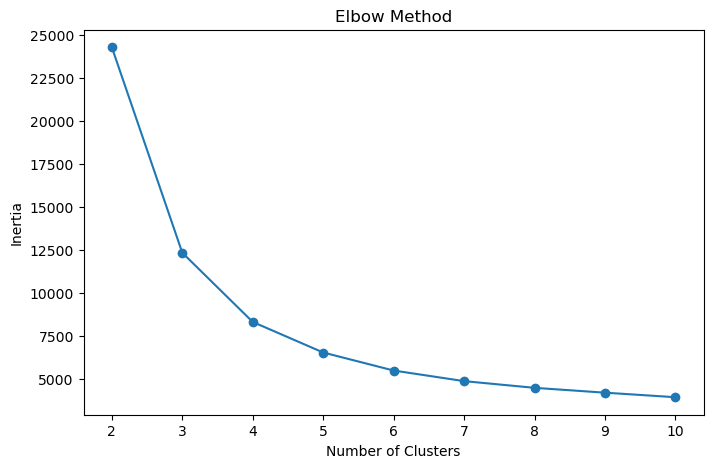

In [36]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

for k in range(2,11):

    km = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    km.fit(cluster_scaled)

    inertia.append(km.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(2,11), inertia, marker="o")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

In [12]:
scores = []

for k in range(2,11):

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = model.fit_predict(cluster_scaled)

    score = silhouette_score(
        cluster_scaled,
        labels
    )

    scores.append(score)

    print(f"K={k}  Score={score:.4f}")

K=2  Score=0.2403
K=3  Score=0.2415
K=4  Score=0.2437
K=5  Score=0.2278
K=6  Score=0.2318
K=7  Score=0.2497
K=8  Score=0.2621
K=9  Score=0.2483
K=10  Score=0.2427


In [37]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

customer_df["Cluster"] = kmeans.fit_predict(cluster_scaled)

customer_df.head()

,Customer Id,Customer_Total_Orders,Order_Item_Total,Order_Item_Quantity,Order_Item_Discount,Cluster
0,1,1,472.450012,5,27.500000,3
1,2,10,1618.660042,19,201.070000,0
2,3,18,3189.200037,33,348.480002,2
3,4,14,1480.709993,34,238.920006,0
4,5,7,1101.919998,18,172.830000,0


In [38]:
cluster_summary = customer_df.groupby("Cluster").mean(numeric_only=True).round(2)

cluster_summary

,Customer Id,Customer_Total_Orders,Order_Item_Total,Order_Item_Quantity,Order_Item_Discount
Cluster,,,,,
0,6262.74,9.81,1723.36,21.05,190.90
1,6226.66,26.05,4761.35,57.98,551.32
2,6209.86,16.95,3052.77,37.08,345.73
3,15169.67,1.39,315.83,1.94,34.43


In [39]:
cluster_names = {
    0: "Regular Customers",
    1: "Premium Customers",
    2: "Frequent Customers",
    3: "Occasional Customers"
}

customer_df["Segment"] = customer_df["Cluster"].map(cluster_names)

In [40]:
customer_df.to_csv("customer_segments.csv", index=False)

In [41]:
import joblib

joblib.dump(kmeans, "customer_segmentation_kmeans.pkl")

print("KMeans model saved successfully!")

KMeans model saved successfully!


In [42]:
joblib.dump(scaler, "customer_segmentation_scaler.pkl")

print("Scaler saved successfully!")

Scaler saved successfully!


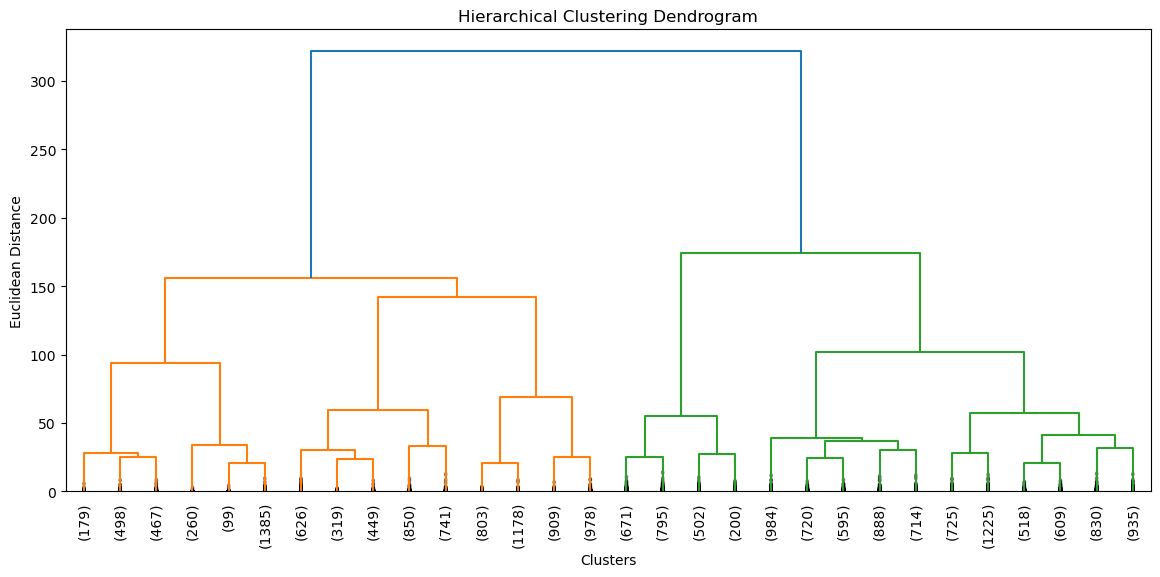

In [26]:
from scipy.cluster.hierarchy import linkage, dendrogram
import matplotlib.pyplot as plt

# Ward linkage
linked = linkage(cluster_scaled, method='ward')

plt.figure(figsize=(14,6))

dendrogram(
    linked,
    truncate_mode='lastp',
    p=30,
    leaf_rotation=90,
    leaf_font_size=10,
    show_contracted=True
)

plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Clusters")
plt.ylabel("Euclidean Distance")

plt.show()

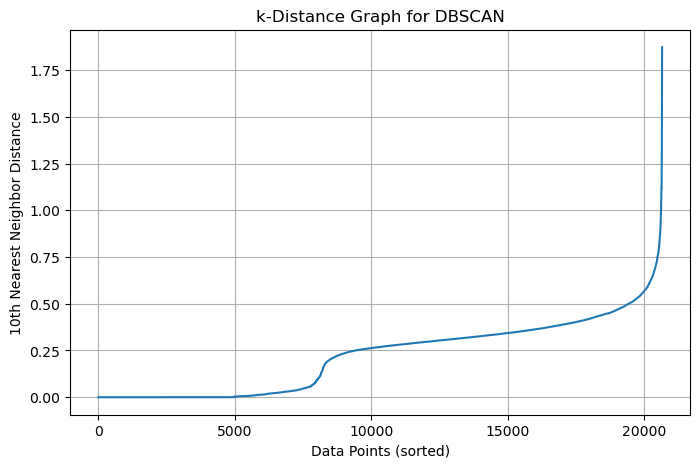

In [27]:
from sklearn.neighbors import NearestNeighbors
import numpy as np
import matplotlib.pyplot as plt

min_samples = 10

neighbors = NearestNeighbors(n_neighbors=min_samples)
neighbors_fit = neighbors.fit(cluster_scaled)

distances, indices = neighbors_fit.kneighbors(cluster_scaled)

# Sort the distance to the 10th nearest neighbor
distances = np.sort(distances[:, min_samples - 1])

plt.figure(figsize=(8,5))
plt.plot(distances)
plt.xlabel("Data Points (sorted)")
plt.ylabel("10th Nearest Neighbor Distance")
plt.title("k-Distance Graph for DBSCAN")
plt.grid(True)
plt.show()

In [28]:
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score
import numpy as np

eps_values = [0.5, 0.6, 0.7]

for eps in eps_values:

    dbscan = DBSCAN(
        eps=eps,
        min_samples=10
    )

    labels = dbscan.fit_predict(cluster_scaled)

    # Number of clusters (excluding noise)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)

    # Number of noise points
    n_noise = np.sum(labels == -1)

    print("="*50)
    print(f"eps = {eps}")
    print(f"Clusters Found : {n_clusters}")
    print(f"Noise Points   : {n_noise}")

    # Silhouette Score
    mask = labels != -1

    if n_clusters > 1 and np.sum(mask) > n_clusters:
        score = silhouette_score(cluster_scaled[mask], labels[mask])
        print(f"Silhouette Score : {score:.4f}")
    else:
        print("Silhouette Score : Not Applicable")

eps = 0.5
Clusters Found : 8
Noise Points   : 421
Silhouette Score : -0.0542
eps = 0.6
Clusters Found : 7
Noise Points   : 172
Silhouette Score : 0.0739
eps = 0.7
Clusters Found : 6
Noise Points   : 66
Silhouette Score : 0.1866


In [29]:
comparison = pd.DataFrame({
    "Algorithm": [
        "K-Means",
        "Hierarchical Clustering",
        "DBSCAN (eps=0.7)"
    ],
    "Clusters": [
        4,
        4,
        6
    ],
    "Silhouette Score": [
        0.2437,
        0.2437,   # replace with your Agglomerative score if you computed it
        0.1866
    ],
    "Remarks": [
        "Selected Final Model",
        "Confirms K=4",
        "Lower clustering quality"
    ]
})

comparison

,Algorithm,Clusters,Silhouette Score,Remarks
0,K-Means,4,0.2437,Selected Final Model
1,Hierarchical Clustering,4,0.2437,Confirms K=4
2,DBSCAN (eps=0.7),6,0.1866,Lower clustering quality


# Customer Segmentation using Unsupervised Machine Learning

## Project Objective

The objective of this notebook is to perform **customer segmentation** using unsupervised machine learning techniques. Unlike the classification model, which predicts whether an order is at risk of late delivery, this analysis aims to group customers with similar purchasing behavior into meaningful segments.

Customer segmentation helps businesses understand different types of customers and enables targeted marketing strategies, personalized promotions, improved customer retention, and better business decision-making.

---

# Dataset Preparation

The original dataset contains **order-level transactions**, where each row represents a single order placed by a customer.

Since the goal is customer segmentation, the data was first transformed into a **customer-level dataset** by aggregating all orders belonging to the same customer using **Customer Id**.

The following customer-level features were created:

* **Customer_Total_Orders** – Total number of orders placed by each customer.
* **Order_Item_Total** – Total amount spent by each customer.
* **Order_Item_Quantity** – Total quantity of products purchased.
* **Order_Item_Discount** – Total discount received across all purchases.

These features represent customer purchasing behavior and are more suitable for segmentation than individual order records.

---

# Feature Selection

Only behavioral features that describe customer purchasing patterns were selected for clustering.

The final features used were:

* Customer_Total_Orders
* Order_Item_Total
* Order_Item_Quantity
* Order_Item_Discount

The following variables were intentionally excluded:

* **Customer Id** – Used only as a unique identifier for grouping customers and not as a clustering feature.
* **Avg_Scheduled_Days** – Represents the company's logistics planning rather than customer behavior.
* **Avg_Discount_to_Sales** – Showed very little variation across customers and therefore did not contribute meaningfully to cluster formation.

---

# Data Standardization

The selected numerical features were standardized using **StandardScaler**.

Since clustering algorithms such as K-Means, Hierarchical Clustering, and DBSCAN are distance-based methods, standardization ensures that variables with larger numerical ranges do not dominate the clustering process.

---

# K-Means Clustering

K-Means clustering was used as the primary customer segmentation algorithm because it is efficient, scalable, and widely adopted for customer analytics.

The algorithm partitions customers into groups by minimizing the distance between customers and the centroid of their assigned cluster.

---

# Determining the Optimal Number of Clusters

Several techniques were used to determine the appropriate number of customer segments.

### 1. Elbow Method

The Elbow Method was used to evaluate the Within-Cluster Sum of Squares (WCSS) for different values of **K**.

The curve showed a noticeable bend around **K = 4**, indicating that increasing the number of clusters beyond four produced only marginal improvements.

---

### 2. Silhouette Analysis

Silhouette Scores were calculated for multiple values of **K** to measure cluster cohesion and separation.

Although slightly higher scores were observed for larger values of K, the improvements were relatively small and resulted in additional clusters that were less interpretable from a business perspective.

---

### 3. Hierarchical Clustering

Hierarchical Clustering was performed using **Ward linkage**, and a dendrogram was generated.

The dendrogram showed a natural separation into approximately four major groups, providing independent validation for the value suggested by the Elbow Method.

---

### 4. DBSCAN

DBSCAN was evaluated as an alternative density-based clustering algorithm.

Unlike K-Means, DBSCAN does not require specifying the number of clusters in advance and is capable of identifying noise points and outliers.

Multiple values of the **eps** parameter were tested using the k-distance graph. Although DBSCAN identified several clusters, its best silhouette score was lower than that of K-Means, indicating weaker cluster separation for this dataset.

Therefore, DBSCAN was used as a comparison technique rather than the final clustering model.

---

# Final Model Selection

After comparing multiple clustering approaches:

* Elbow Method
* Silhouette Analysis
* Hierarchical Clustering
* DBSCAN

**K-Means with K = 4** was selected as the final clustering model.

This choice provided the best balance between statistical performance and business interpretability.

---

# Customer Segments Identified

The final model identified four meaningful customer segments based on purchasing behavior:

* **Premium Customers** – Highest order frequency, spending, and purchase quantity.
* **Frequent Customers** – Regular purchasers with high but not maximum spending.
* **Regular Customers** – Moderate purchasing behavior representing the core customer base.
* **Occasional Customers** – Customers with low purchase frequency and low spending.

These segments provide actionable insights for personalized marketing, loyalty programs, cross-selling opportunities, and customer retention strategies.

---

# Business Impact

The customer segmentation model enables the business to:

* Identify high-value customers for loyalty and retention initiatives.
* Increase revenue through personalized recommendations and upselling.
* Design targeted marketing campaigns for different customer groups.
* Improve customer engagement by understanding purchasing behavior.
* Support data-driven decision-making for sales and marketing teams.

This clustering analysis complements the Late Delivery Risk classification model by providing customer-centric insights in addition to operational risk prediction.
